- print(df.columns)# 이상여부확인 컬럼 개수, 컬럼명 여부, 이상 컬럼 존재여부, 
                # 헤더 이상 여부 확인
- print(df.index[:5]) # 원래 데이터 값이 정상 자리에 있는 지  1,2,3,4,
- print(df.iloc[0].tolist()) - # ioc는 행/열의 위치 번호로 데이터 선택 시 사용 --> 시리즈
-                           - # tolist() 넘파이 객체 값들을 파이썬 리스트 형태로 변환
- print(df.columns.tolist())
- print(df.shape)
- print(df.head())
- print(df.isna().sum())
- print(df.info())

#### df4
- df4_long
- df4_time_summary
- 시간대별 혼잡도

##### df4_time_summary
- df4_station_summary
- 역별 평균 혼잡도

#### usage_summary + df4_station_summary
- station_analysis_df
- 산점도·상관검정

#### usage_summary + df4_time_summary
- time_analysis_df
- 최고 혼잡 시간대 분석

### 지하철 승하차 이용정보 - df1
- ['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '등록일자']
- 교통카드(선후불교통카드 및 1회용 교통카드)를 이용한 지하철호선별 역별(서울교통공사, 한국철도공사, 공항철도, 9호선) 승하차인원을 나타내는 정보입니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import scipy.stats as stats

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

# df1=pd.read_csv("../data/실습데이터/2_7.CARD_SUBWAY_MONTH_202607.csv",
#                encoding='utf-8', 
#                index_col=False)#index_col=False csv 안에 열을 df 인덱스로 사용하는 것 off
# df1.tail()


files = [
    "../data/실습데이터/2_4.CARD_SUBWAY_MONTH_202604.csv",
    "../data/실습데이터/2_5.CARD_SUBWAY_MONTH_202605.csv",
    "../data/실습데이터/2_6.CARD_SUBWAY_MONTH_202606.csv"
]

df1_list = [
    pd.read_csv(
        file,
        encoding='utf-8-sig',
        index_col=False
    )
    for file in files
]

df1_승하차 = pd.concat(
    df1_list,
    ignore_index=True
)



print(df1_승하차.shape)
print(df1_승하차.columns.tolist())
print(df1_승하차['사용일자'].min())
print(df1_승하차['사용일자'].max())

(56165, 6)
['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수', '등록일자']
20260401
20260630


In [3]:
# 승차·하차 인원 숫자형 변환
df1_승하차['승차총승객수'] = pd.to_numeric(
    df1_승하차['승차총승객수'],
    errors='coerce'
)

df1_승하차['하차총승객수'] = pd.to_numeric(
    df1_승하차['하차총승객수'],
    errors='coerce'
)

# 총 이용량 생성
df1_승하차['이용량'] = (
    df1_승하차['승차총승객수'] + df1_승하차['하차총승객수']
)
#역별 3개 월 이용량 집계
usage_summary = (
    df1_승하차
    .groupby(['노선명', '역명'], as_index=False)
    .agg(
        승차인원=('승차총승객수', 'sum'),
        하차인원=('하차총승객수', 'sum'),
        이용량=('이용량', 'sum')
    )
    .sort_values(
        by='이용량',
        ascending=False
    )
)

usage_summary.head()

,노선명,역명,승차인원,하차인원,이용량
52,2호선,잠실(송파구청),7659336,7527837,15187173
2,1호선,서울역,7297935,7124550,14422485
59,2호선,홍대입구,6936892,7426182,14363074
10,2호선,강남,7127203,6979583,14106786
31,2호선,성수,5246449,5605886,10852335


### 자료형 파악 필수 
- 변수[['컬럼1','컬럼2','컬럼3']].dtypes

In [ ]:

df1_승하차[['승차총승객수','하차총승객수','이용량']].dtypes 


승차총승객수    int64
하차총승객수    int64
이용량       int64
dtype: object

In [5]:
#숫자형 변환
usage_cols = [
    '승차총승객수',
    '하차총승객수'
]

df1_승하차[usage_cols] = (
    df1_승하차[usage_cols]
    .apply(pd.to_numeric, errors='coerce')
)

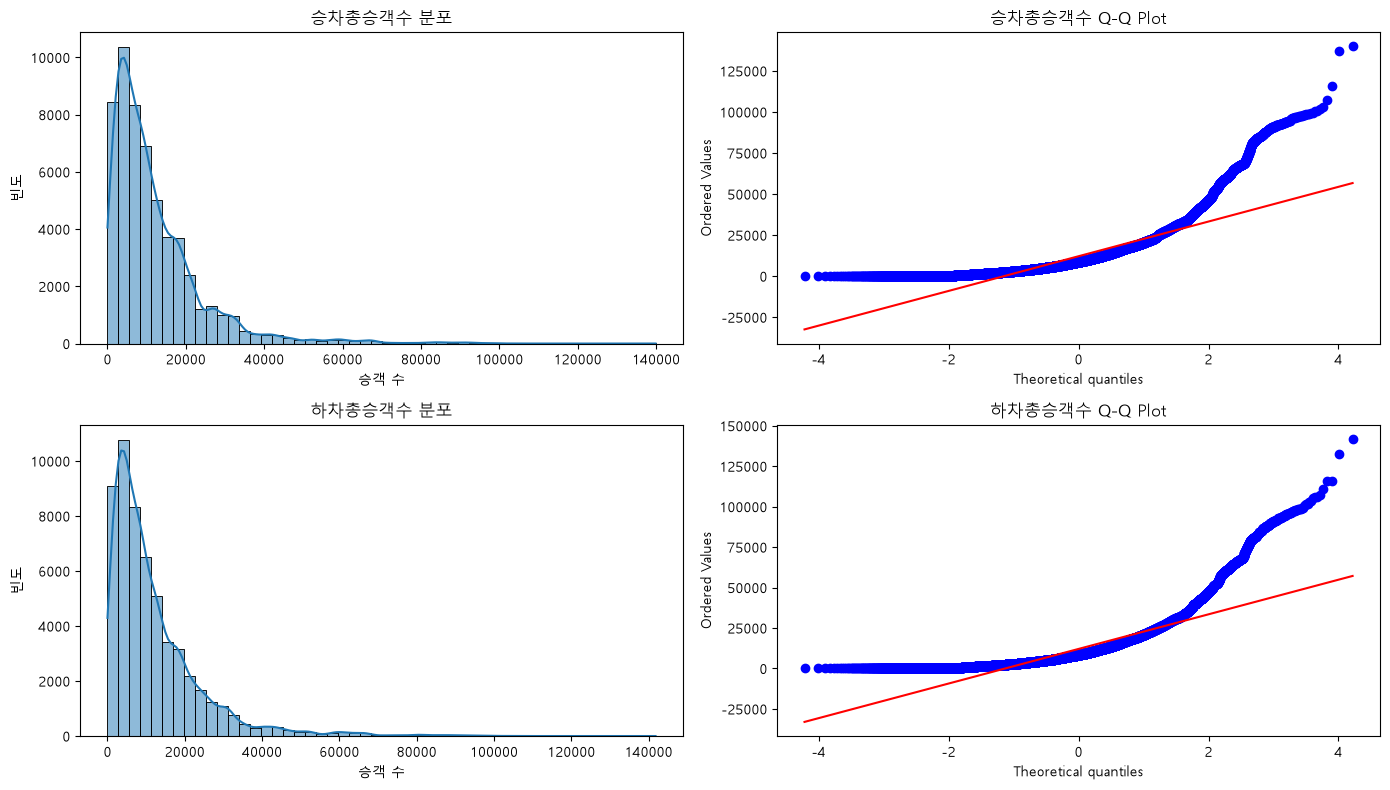

In [6]:
# 분포도 확인
df1_승하차[usage_cols].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max',
    'skew'
])


fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8)
)

for i, col in enumerate(usage_cols):
    values = df1_승하차[col].dropna()

    sns.histplot(
        values,
        bins=50,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f'{col} 분포')
    axes[i, 0].set_xlabel('승객 수')
    axes[i, 0].set_ylabel('빈도')

    stats.probplot(
        values,
        dist='norm',
        plot=axes[i, 1]
    )

    axes[i, 1].set_title(f'{col} Q-Q Plot')

plt.tight_layout()
plt.show()


- 왼쪽으로 쏠려있고 오른쪽으로 길게 늘어져 있어서 정규분포는 아니고 우측왜도이다

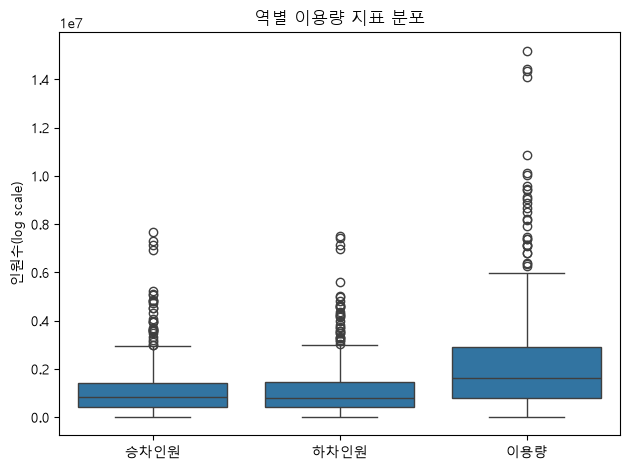

In [7]:
#이용량 박스 플룻 확인
sub = [
    '승차인원',
    '하차인원',
    '이용량'
]

plot_df = usage_summary[sub].melt(
    var_name='지표',
    value_name='값'
)

plot_df = plot_df[
    plot_df['값'] > 0
]

sns.boxplot(
    data=plot_df,
    x='지표',
    y='값',
    order=sub
)

# plt.yscale('log')
plt.title('역별 이용량 지표 분포')
plt.xlabel('')
plt.ylabel('인원수(log scale)')
plt.tight_layout()
plt.show()

# 이상치로 보일 수 있으나 사람이 많은 역, 로그로 스캐일 하고 보았을 때도 이상이 있어도 주요 역은 제외하면 안된다

In [8]:
#이상치는 삭제하지 않고 실제 역인지 확인합니다.

q1 = usage_summary['이용량'].quantile(0.25)
q3 = usage_summary['이용량'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

outlier_df = (
    usage_summary[
        usage_summary['이용량'] > upper_limit
    ]
    .sort_values(
        by='이용량',
        ascending=False
    )
    .copy()
)

outlier_df['역표시'] = (
    outlier_df['노선명'] +
    ' - ' +
    outlier_df['역명']
)

outlier_df

,노선명,역명,승차인원,하차인원,이용량,역표시
52,2호선,잠실(송파구청),7659336,7527837,15187173,2호선 - 잠실(송파구청)
2,1호선,서울역,7297935,7124550,14422485,1호선 - 서울역
59,2호선,홍대입구,6936892,7426182,14363074,2호선 - 홍대입구
10,2호선,강남,7127203,6979583,14106786,2호선 - 강남
31,2호선,성수,5246449,5605886,10852335,2호선 - 성수
37,2호선,신림,5107277,5008126,10115403,2호선 - 신림
14,2호선,구로디지털단지,5059323,4983248,10042571,2호선 - 구로디지털단지
50,2호선,을지로입구,4743251,4830932,9574183,2호선 - 을지로입구
63,3호선,고속터미널,4855321,4593584,9448905,3호선 - 고속터미널
26,2호선,삼성(무역센터),4803039,4629501,9432540,2호선 - 삼성(무역센터)


In [9]:
## 2. 원본 데이터에서 정상 여부
outlier_stations = outlier_df['역명'].tolist()

df1_승하차[
    df1_승하차['역명'].isin(outlier_stations)
].sort_values(
    by=['역명', '사용일자']
)[
    ['사용일자', '노선명', '역명','승차총승객수', '하차총승객수', '이용량']
]

,사용일자,노선명,역명,승차총승객수,하차총승객수,이용량
20,20260401,7호선,가산디지털단지,52486,53477,105963
248,20260401,경부선,가산디지털단지,20704,24064,44768
776,20260402,7호선,가산디지털단지,52292,53556,105848
1160,20260402,경부선,가산디지털단지,21054,24046,45100
1500,20260403,경부선,가산디지털단지,20817,23831,44648
...,...,...,...,...,...,...
55457,20260629,경의선,홍대입구,2114,2434,4548
55547,20260629,2호선,홍대입구,70054,73943,143997
55680,20260630,2호선,홍대입구,69862,73491,143353
56034,20260630,경의선,홍대입구,2187,2417,4604


In [10]:
#역별이용량
top10 = (
usage_summary
.sort_values(
by='이용량',
ascending=False
)
.head(10)
.copy()
)

top10['역표시'] = (
top10['노선명'] + ' - ' + top10['역명']
)

top10 = top10.sort_values(
by='이용량',
ascending=True
)
fig = px.bar(
    top10,
    x='이용량',
    y='역표시',
    orientation='h',
    hover_data=['노선명', '역명', '승차인원', '하차인원'],
    title='이용량 상위 10개 역'
)
fig.show()



# plt.figure(figsize=(10, 6))

# sns.barplot(
# data=top10,
# x='이용량',
# y='역표시',
# color='steelblue'
# )


# plt.title('이용량 상위 10개 역')
# plt.xlabel('3개월 총 이용량')
# plt.ylabel('역')
# plt.tight_layout()
# plt.show()

In [11]:
#역별 많은역
plot_outlier = outlier_df.sort_values(
    by='이용량',
    ascending=True
)

fig = px.bar(
    plot_outlier,
    x='이용량',
    y='역표시',
    orientation='h',
    hover_data={
        '노선명': True,
        '역명': True,
        '승차인원': ':,',
        '하차인원': ':,',
        '이용량': ':,'
    },
    title='이용량 많은 역'
)

fig.update_layout(
    xaxis_title='3개월 총 이용량',
    yaxis_title='역',
    hovermode='closest'
)

fig.show()

In [12]:
############################################# 
# test_df = analysis_df[
#     ['이용량', '평균혼잡도']
# ].dropna()
##############################################
rho, p_value = spearmanr(
    test_df['이용량'],
    test_df['평균혼잡도']
)

print('Spearman 상관계수:', rho)
print('p-value:', p_value)

NameError: name 'spearmanr' is not defined

### 서울교통공사_환승역환승인원정보 -df2
- ['출발역명', '평일', '토요일', '일요일']

In [ ]:
df2=pd.read_excel("../data/실습데이터/1_서울교통공사_환승역환승인원정보_20260630.xlsx"
               )#index_col=False csv 안에 열을 df 인덱스로 사용하는 것 off
df2 = df2.drop(columns=["연번"]).reset_index(drop=True)
df2.tail(10)
# df2.columns

,출발역명,평일,토요일,일요일
63,불광,23300.4,18364,13631
64,수서,22313.4,16971,11692
65,보라매,22063.8,11949,9016
66,양재,21161.4,14912,9689
67,모란,20650.0,15058,10857
68,충정로,20542.4,10576,7720
69,보문,18099.0,11780,8755
70,신내,9588.6,7387,5650
71,효창공원앞,8130.0,6979,5200
72,강동,6568.8,4733,3812


In [ ]:
df2[['출발역명','평일','토요일','일요일']].sort_values( # 2개 이상 컬럼 조회시 [] 대괄호 추가
    by='평일',
    ascending=False
)
df2.head(10)

,출발역명,평일,토요일,일요일
0,신도림,262670.0,213672,150192
1,동대문역사문화공원,227216.6,186273,131354
2,고속터미널,185639.2,157821,112546
3,왕십리,172392.2,129670,89408
4,서울역,162895.8,143881,105007
5,사당,160478.4,136422,93778
6,종로3가,151327.2,137650,88484
7,교대,138703.2,95096,63892
8,충무로,136404.2,111220,74677
9,잠실,122826.6,80236,54456


## 25년 9호선 역 및 시간별 혼잡도 -df3
- ['구분', '05:30~05:59', '06:00~06:29', '06:30~06:59', '07:00~07:29',
       '07:30~07:59', '08:00~08:29', '08:30~08:59', '09:00~09:29',
       '09:30~09:59', '10:00~10:29', '10:30~10:59', '11:00~11:29',
       '11:30~11:59', '12:00~12:29', '12:30~12:59', '13:00~13:29',
       '13:30~13:59', '14:00~14:29', '14:30~14:59', '15:00~15:29',
       '15:30~15:59', '16:00~16:29', '16:30~16:59', '17:00~17:29',
       '17:30~17:59', '18:00~18:29', '18:30~18:59', '19:00~19:29',
       '19:30~19:59', '20:00~20:29', '20:30~20:59', '21:00~21:29',
       '21:30~21:59', '22:00~22:29', '22:30~22:59', '23:00~23:29',
       '23:30~23:59', '00:00~00:29', '00:30~00:59']

In [ ]:
df3=pd.read_excel("../data/실습데이터/4_2025년 9호선 역별 시간별 혼잡도 자료.xlsx")
df3.columns = df3.iloc[0] # 컬럼 미지정 항목으로 0번행을 컬럼으로 지정
df3_clean = df3.iloc[1:].reset_index(drop=True) # 0번 행을 컬럼으로 지정하였음으로 0번행 삭제
                                                # df4_clean 으로 변수 새로 지정
df3.head(10)
df3_clean.columns

Index(['구분', '05:30~05:59', '06:00~06:29', '06:30~06:59', '07:00~07:29',
       '07:30~07:59', '08:00~08:29', '08:30~08:59', '09:00~09:29',
       '09:30~09:59', '10:00~10:29', '10:30~10:59', '11:00~11:29',
       '11:30~11:59', '12:00~12:29', '12:30~12:59', '13:00~13:29',
       '13:30~13:59', '14:00~14:29', '14:30~14:59', '15:00~15:29',
       '15:30~15:59', '16:00~16:29', '16:30~16:59', '17:00~17:29',
       '17:30~17:59', '18:00~18:29', '18:30~18:59', '19:00~19:29',
       '19:30~19:59', '20:00~20:29', '20:30~20:59', '21:00~21:29',
       '21:30~21:59', '22:00~22:29', '22:30~22:59', '23:00~23:29',
       '23:30~23:59', '00:00~00:29', '00:30~00:59'],
      dtype='object', name=0)

### 지하철혼잡도 시간대별 및 지하철 정보 포함 - df4

['요일구분', '호선', '역번호', '출발역', '상하구분', '5시30분', '6시00분', '6시30분', '7시00분',
       '7시30분', '8시00분', '8시30분', '9시00분', '9시30분', '10시00분', '10시30분',
       '11시00분', '11시30분', '12시00분', '12시30분', '13시00분', '13시30분', '14시00분',
       '14시30분', '15시00분', '15시30분', '16시00분', '16시30분', '17시00분', '17시30분',
       '18시00분', '18시30분', '19시00분', '19시30분', '20시00분', '20시30분', '21시00분',
       '21시30분', '22시00분', '22시30분', '23시00분', '23시30분', '00시00분', '00시30분']

In [15]:
df4=pd.read_csv("../data/실습데이터/5_서울교통공사_지하철혼잡도정보.csv",encoding='cp949')
df4.head()

,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1호선,150,서울역,상선,8.3,20.8,21.3,37.4,65.8,...,19.3,18.3,19.1,15.6,16.1,17.4,14.5,8.6,5.6,1.4
1,평일,1호선,150,서울역,하선,10.5,11.2,16.7,22.9,38.6,...,39.2,37.9,41.2,37.0,38.7,28.4,17.4,11.3,8.4,0.0
2,평일,1호선,151,시청,상선,6.9,15.4,18.1,29.4,49.1,...,23.1,22.7,23.8,18.8,20.3,20.9,17.4,9.9,6.8,1.5
3,평일,1호선,151,시청,하선,8.5,10.4,16.6,21.7,36.9,...,35.2,34.8,39.7,30.4,34.2,24.2,15.2,10.0,5.5,0.3
4,평일,1호선,152,종각,상선,6.3,13.5,11.1,19.3,28.0,...,30.9,29.7,32.8,24.8,27.0,27.0,23.6,12.3,7.7,1.4


In [17]:
# 컬럼명 정리
df4 = df4.rename(columns={
    df4.columns[1]: '호선',
    df4.columns[3]: '역명'
})

# 기준 컬럼 / 시간대 컬럼 구분
id_cols = df4.columns[:5].tolist()
time_cols = df4.columns[5:].tolist()


# Wide → Long 변환
df4_long = df4.melt(
    id_vars=id_cols,
    value_vars=time_cols,
    var_name='시간대',
    value_name='혼잡도'
)

# 혼잡도 숫자형 변환
df4_long['혼잡도'] = pd.to_numeric(
    df4_long['혼잡도'],
    errors='coerce'
)

df4_long.head()

,요일구분,호선,역번호,역명,상하구분,시간대,혼잡도
0,평일,1호선,150,서울역,상선,5시30분,8.3
1,평일,1호선,150,서울역,하선,5시30분,10.5
2,평일,1호선,151,시청,상선,5시30분,6.9
3,평일,1호선,151,시청,하선,5시30분,8.5
4,평일,1호선,152,종각,상선,5시30분,6.3


In [18]:
# 역,시간대별 혼잡도
df4_time_summary = (
    df4_long
    .groupby(
        ['요일구분','호선', '역명', '시간대','상하구분','시간대'],
        as_index=False
    )
    .agg(
        평균혼잡도=('혼잡도', 'mean')
    )
    .sort_values(
        by='평균혼잡도',
        ascending=False
    )
)

df4_time_summary.head()

,요일구분,호선,역명,상하구분,시간대,평균혼잡도
63368,평일,8호선,강동구청,하선,8시00분,159.4
64694,평일,8호선,천호,하선,8시00분,152.5
63758,평일,8호선,몽촌토성,하선,8시00분,150.8
45235,평일,2호선,사당,외선,8시30분,150.4
45079,평일,2호선,방배,외선,8시30분,147.3


In [19]:
#역별 전체 평균과 최고 혼잡도 계산
df4_station_summary = (
    df4_time_summary
    .groupby(
        ['호선', '역명'],
        as_index=False
    )
    .agg(
        전체평균혼잡도=('평균혼잡도', 'mean'),
        최고혼잡도=('평균혼잡도', 'max')
    )
    .sort_values(
        by='최고혼잡도',
        ascending=False
    )
)

df4_station_summary.head()

,호선,역명,전체평균혼잡도,최고혼잡도
263,8호선,강동구청,43.134615,159.4
280,8호선,천호,35.155983,152.5
268,8호선,몽촌토성,44.641026,150.8
26,2호선,사당,44.856410,150.4
24,2호선,방배,45.532051,147.3


In [ ]:
# df4_time_summary(df_log) + df4_time_summary(df4_time) 데이터 결합
station_analysis_df = (
      df4_station_summary
      .merge(
          usage_summary,
          left_on=['호선', '역명'],
          right_on=['노선명', '역명'],
          how='inner'
      )
  )

station_analysis_df[
    [
        '호선',
        '역명',
        '이용량',
        '전체평균혼잡도',
        '최고혼잡도'
    ]
].head()

,호선,역명,이용량,전체평균혼잡도,최고혼잡도
0,4호선,남태령,251638,46.056410,84.333333
1,8호선,석촌,1824555,50.050000,82.850000
2,8호선,송파,1802308,50.073504,78.250000
3,8호선,가락시장,1590564,46.084615,74.350000
4,4호선,동대문,3760670,46.986752,71.083333


In [ ]:
fig = px.scatter(
    data_frame=station_analysis_df,
    x='이용량',
    y='전체평균혼잡도',
    hover_data={
        '호선': True,
        '역명': True,
        '이용량': ':,',
        '전체평균혼잡도': ':.2f',
        '최고혼잡도': ':.2f'
    },
    title='전체 역의 이용량과 평균혼잡도 관계'
)

fig.update_layout(
    xaxis_title='3개월 이용량',
    yaxis_title='전체평균혼잡도'
)

fig.show()
#   오른쪽 위에 있는 역이 핵심 분석 대상입니다.

#   오른쪽 위 → 이용량 높음·혼잡도 높음
#   오른쪽 아래 → 이용량 높음·혼잡도 낮음
#   왼쪽 위 → 이용량 낮음·혼잡도 높음
#   왼쪽 아래 → 이용량 낮음·혼잡도 낮음

In [ ]:
#상관검정
from scipy.stats import spearmanr

test_df = station_analysis_df[
    ['이용량', '전체평균혼잡도']
].dropna()

rho, p_value = spearmanr(
    test_df['이용량'],
    test_df['전체평균혼잡도']
)

print('분석 역 개수:', len(test_df))
print(f'Spearman 상관계수: {rho:.4f}')
print(f'p-value: {p_value:.10e}')

분석 역 개수: 211
Spearman 상관계수: 0.4072
p-value: 7.8595029906e-10


In [ ]:
### 7단계: 시간대별 분석

#시간대별 분석은 별도 DataFrame을 사용합니다.

time_analysis_df = df4_time_summary.merge(
    usage_summary,
    left_on=['호선', '역명'],
    right_on=['노선명', '역명'],
    how='inner'
)

#최고 혼잡 시간대를 찾습니다.

peak_idx = (
    time_analysis_df
    .groupby(['호선', '역명'])['평균혼잡도']
    .idxmax()
)

peak_time_analysis = (
    time_analysis_df
    .loc[peak_idx]
    .reset_index(drop=True)
)

peak_time_analysis.sort_values(by='이용량', 
                              ascending=False).head()

,호선,역명,시간대,평균혼잡도,노선명,승차인원,하차인원,이용량
2,1호선,서울역,18시00분,57.483333,1호선,7297935,7124550,14422485
45,2호선,홍대입구,17시30분,55.466667,2호선,6936892,7426182,14363074
9,2호선,강남,18시00분,70.016667,2호선,7127203,6979583,14106786
22,2호선,성수,18시00분,23.608333,2호선,5246449,5605886,10852335
28,2호선,신림,16시00분,49.616667,2호선,5107277,5008126,10115403


In [ ]:
## 원본 시간대별 평균값 그래프
time_overall = (
    df4_time_summary
    .groupby('시간대', as_index=False)
    .agg(
        평균혼잡도=('평균혼잡도', 'mean')
    )
)

#원본 시간대 
time_order = df4_long['시간대'].drop_duplicates().tolist()

time_overall['시간대'] = pd.Categorical(
    time_overall['시간대'],
    categories=time_order,
    ordered=True
)
time_overall = time_overall.sort_values('시간대')

#그래프 출력
fig = px.line(
    time_overall,
    x='시간대',
    y='평균혼잡도',
    markers=True,
    hover_data={
        '시간대': True,
        '평균혼잡도': ':.2f'
    },
    title='시간대별 평균 혼잡도'
)

fig.update_layout(
    xaxis_title='시간대',
    yaxis_title='평균혼잡도',
    xaxis_tickangle=-45
)

fig.show()

In [ ]:
peak_plot_df = peak_time_analysis.copy()

peak_plot_df['역표시'] = (
peak_plot_df['호선'] +
' - ' +
peak_plot_df['역명']
)

peak_plot_df = peak_plot_df.rename(
    columns={
        '시간대': '최고혼잡시간대',
        '평균혼잡도': '최고혼잡도'
    }
)

peak_plot_df = peak_plot_df.sort_values(
by='이용량',
ascending=True
)

fig = px.bar(
peak_plot_df,
x='이용량',
y='역표시',
orientation='h',
color='최고혼잡도',
color_continuous_scale='RdYlGn_r',
hover_data={
    '호선': True,
    '역명': True,
    '이용량': ':,',
    '최고혼잡시간대': True,
    '최고혼잡도': ':.2f'
},
title='전체 역의 이용량과 최고 혼잡 시간대',
height=2200
)

fig.update_layout(
xaxis_title='3개월 이용량',
yaxis_title='역',
coloraxis_colorbar={
    'title': '최고혼잡도'
}
)

fig.show()


#### 서울시 행정동별 지하철 총 승차 승객수 정보 -df5
['기준_날짜', '행정동_ID', '지하철_승객_수', '지하철_승객_수_00시', '지하철_승객_수_01시',
       '지하철_승객_수_02시', '지하철_승객_수_03시', '지하철_승객_수_04시', '지하철_승객_수_05시',
       '지하철_승객_수_06시', '지하철_승객_수_07시', '지하철_승객_수_08시', '지하철_승객_수_09시',
       '지하철_승객_수_10시', '지하철_승객_수_11시', '지하철_승객_수_12시', '지하철_승객_수_13시',
       '지하철_승객_수_14시', '지하철_승객_수_15시', '지하철_승객_수_16시', '지하철_승객_수_17시',
       '지하철_승객_수_18시', '지하철_승객_수_19시', '지하철_승객_수_20시', '지하철_승객_수_21시',
       '지하철_승객_수_22시', '지하철_승객_수_23시']

### 5일마다 갱신되는 것을 월, 연 데이터가 아님으로 일단 대기

In [ ]:
# df5=pd.read_csv("../data/실습데이터/3_서울시 행정동별 지하철 총 승차 승객수 정보.csv",encoding='cp949')
# df5.columns
# df5.head(10)